In [ ]:
#Librauries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split




In [ ]:
# Dataset load 
df = pd.read_csv('online_shoppers_intention.csv')
print(df.shape)       # (12330, 18)
print(df.head())
print(df['Revenue'].value_counts())  # Target column


(12330, 18)
   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  \
0         0.20       0.20         0.0         0.0   Feb                 1   
1         0.00       0.10         0.0         

In [ ]:
#DATA UNDERSTANDING

# 1. Data types aur null values
print("="*50)
print("DATASET INFO:")
print("="*50)
df.info()

print("\n" + "="*50)
print("MISSING VALUES:")
print("="*50)
print(df.isnull().sum())

print("\n" + "="*50)
print("BASIC STATISTICS:")
print("="*50)
df.describe()

DATASET INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficT

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


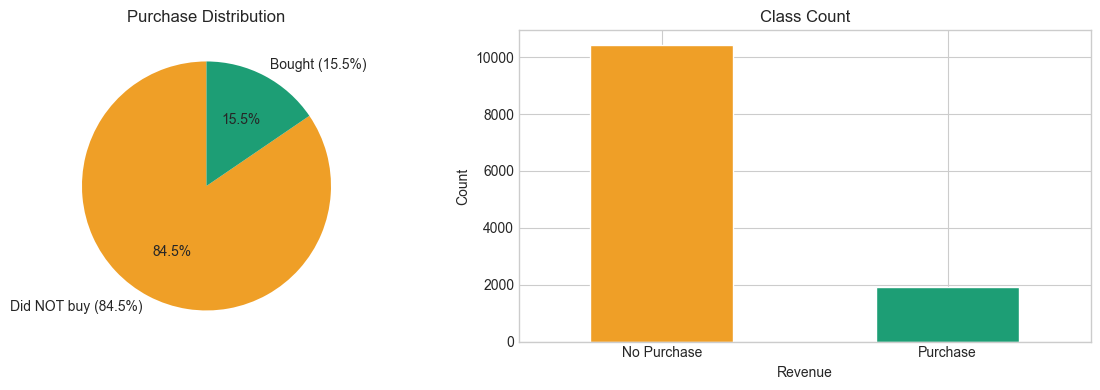

Plot saved!


In [6]:
# 2. Class imbalance visualize karo

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
df['Revenue'].value_counts().plot(
    kind='pie', ax=axes[0],
    labels=['Did NOT buy (84.5%)', 'Bought (15.5%)'],
    colors=['#EF9F27', '#1D9E75'],
    autopct='%1.1f%%', startangle=90
)
axes[0].set_title('Purchase Distribution')
axes[0].set_ylabel('')

# Count bar
df['Revenue'].value_counts().plot(
    kind='bar', ax=axes[1],
    color=['#EF9F27', '#1D9E75'], edgecolor='white'
)
axes[1].set_xticklabels(['No Purchase', 'Purchase'], rotation=0)
axes[1].set_title('Class Count')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

In [7]:
# 3. Categorical features ka overview
print("Unique values per column:")
print("-"*40)
for col in ['Month', 'VisitorType', 'Weekend', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']:
    print(f"{col:20s}: {df[col].unique()}")

Unique values per column:
----------------------------------------
Month               : ['Feb' 'Mar' 'May' 'Oct' 'June' 'Jul' 'Aug' 'Nov' 'Sep' 'Dec']
VisitorType         : ['Returning_Visitor' 'New_Visitor' 'Other']
Weekend             : [False  True]
OperatingSystems    : [1 2 4 3 7 6 8 5]
Browser             : [ 1  2  3  4  5  6  7 10  8  9 12 13 11]
Region              : [1 9 2 3 4 5 6 7 8]
TrafficType         : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 18 19 16 17 20]


In [ ]:
# DATA PREPROCESSING 

from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Categorical columns encode 
le = LabelEncoder()
df['Month']       = le.fit_transform(df['Month'])
df['VisitorType'] = le.fit_transform(df['VisitorType'])
df['Weekend']     = df['Weekend'].astype(int)
df['Revenue']     = df['Revenue'].astype(int)

print("Encoding done!")
print(df[['Month', 'VisitorType', 'Weekend', 'Revenue']].head())

Encoding done!
   Month  VisitorType  Weekend  Revenue
0      2            2        0        0
1      2            2        0        0
2      2            2        0        0
3      2            2        0        0
4      2            2        1        0


In [ ]:
# 2. Features and Target separate 
X = df.drop('Revenue', axis=1)
y = df['Revenue']

print(f"Features shape : {X.shape}")
print(f"Target shape   : {y.shape}")
print(f"Feature columns: {list(X.columns)}")

Features shape : (12330, 17)
Target shape   : (12330,)
Feature columns: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']


In [ ]:
# 3. Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # class balance maintain
)

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"y_train distribution:\n{y_train.value_counts()}")
print(f"y_test  distribution:\n{y_test.value_counts()}")

X_train: (9864, 17)  |  X_test: (2466, 17)
y_train distribution:
Revenue
0    8338
1    1526
Name: count, dtype: int64
y_test  distribution:
Revenue
0    2084
1     382
Name: count, dtype: int64


In [11]:
# 4. Feature Scaling (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # train par fit + transform
X_test_scaled  = scaler.transform(X_test)         # test par sirf transform

print("Scaling done!")
print(f"X_train mean (first 3 cols): {X_train_scaled[:, :3].mean(axis=0).round(4)}")
print(f"X_train std  (first 3 cols): {X_train_scaled[:, :3].std(axis=0).round(4)}")

Scaling done!
X_train mean (first 3 cols): [-0. -0.  0.]
X_train std  (first 3 cols): [1. 1. 1.]


In [ ]:
# 5. Class Imbalance fix - SMOTE
# pip install imbalanced-learn

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After  SMOTE: {dict(zip(*[list(x) for x in [['No Buy','Buy'], [sum(y_train_res==0), sum(y_train_res==1)]]]))}") 
print(f"New training shape: {X_train_res.shape}")

Before SMOTE: {0: 8338, 1: 1526}
After  SMOTE: {'No Buy': 8338, 'Buy': 8338}
New training shape: (16676, 17)


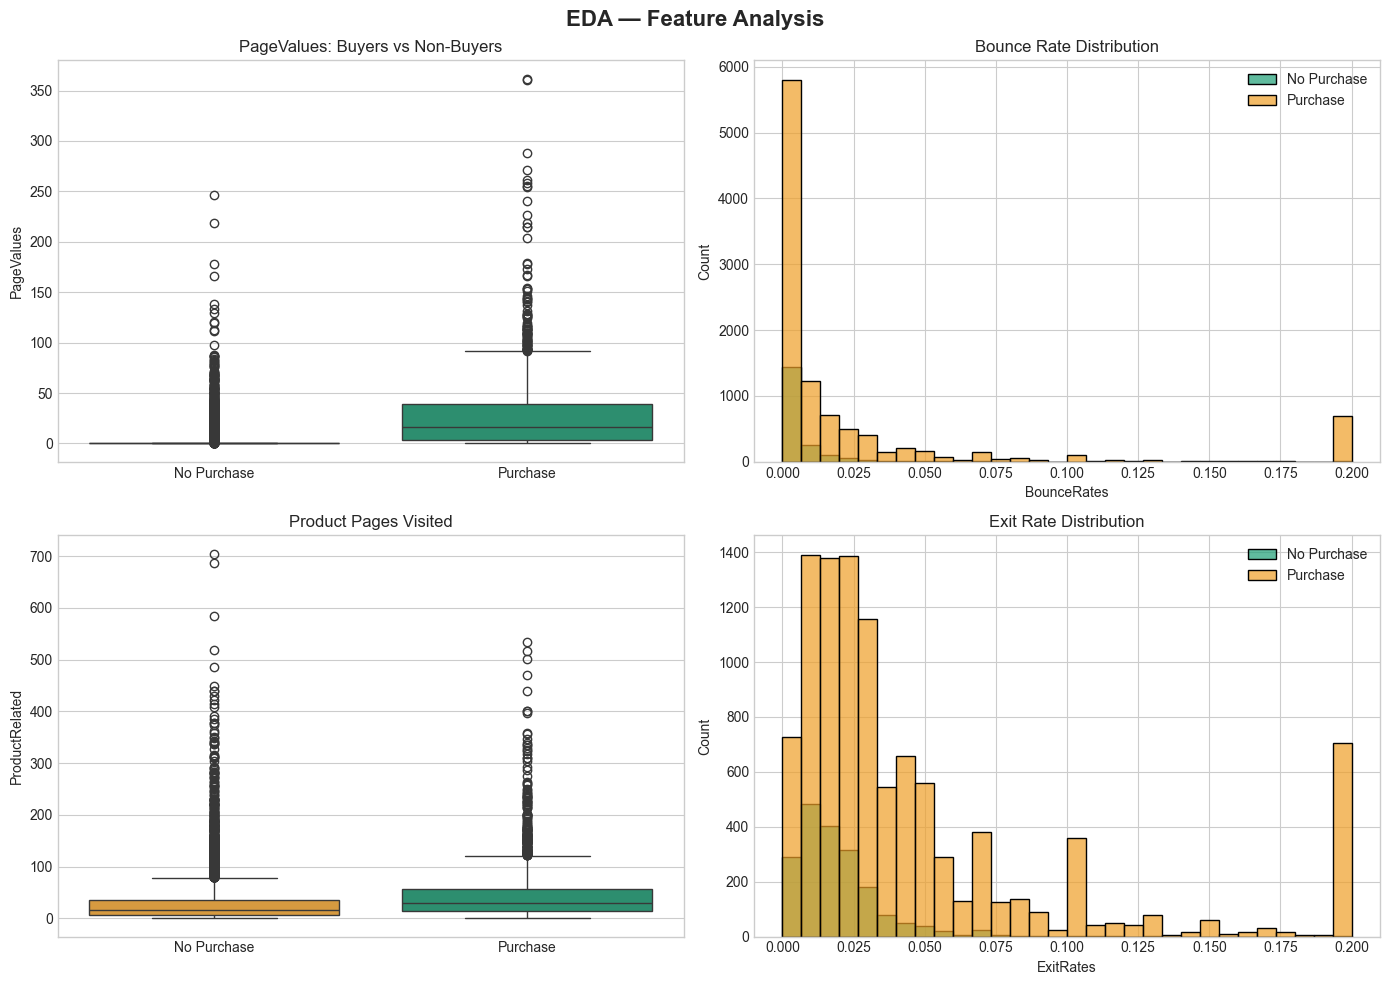

Plot 1 done!


In [ ]:
# EDA

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EDA — Feature Analysis', fontsize=16, fontweight='bold')

# 1. PageValues — buyers vs non-buyers
sns.boxplot(data=df, x='Revenue', y='PageValues',
            hue='Revenue',
            palette=['#EF9F27', '#1D9E75'],
            ax=axes[0,0], legend=False)
axes[0,0].set_title('PageValues: Buyers vs Non-Buyers')
axes[0,0].set_xticklabels(['No Purchase', 'Purchase'])
axes[0,0].set_xlabel('')

# 2. BounceRates distribution
sns.histplot(data=df, x='BounceRates', hue='Revenue',
             palette=['#EF9F27', '#1D9E75'],
             bins=30, ax=axes[0,1], alpha=0.7)
axes[0,1].set_title('Bounce Rate Distribution')
axes[0,1].legend(['No Purchase', 'Purchase'])

# 3. ProductRelated pages visited
sns.boxplot(data=df, x='Revenue', y='ProductRelated',
            hue='Revenue',
            palette=['#EF9F27', '#1D9E75'],
            ax=axes[1,0], legend=False)
axes[1,0].set_title('Product Pages Visited')
axes[1,0].set_xticklabels(['No Purchase', 'Purchase'])
axes[1,0].set_xlabel('')

# 4. ExitRates
sns.histplot(data=df, x='ExitRates', hue='Revenue',
             palette=['#EF9F27', '#1D9E75'],
             bins=30, ax=axes[1,1], alpha=0.7)
axes[1,1].set_title('Exit Rate Distribution')
axes[1,1].legend(['No Purchase', 'Purchase'])

plt.tight_layout()
plt.savefig('02_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 1 done!")

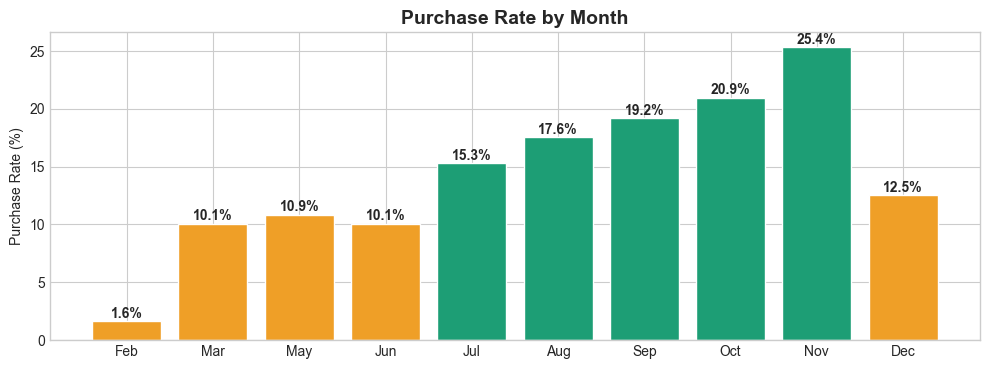

Plot 2 done!


In [15]:
# Monthly Purchase Rate
plt.figure(figsize=(12, 4))

month_names = {0:'Aug', 1:'Dec', 2:'Feb', 3:'Jul', 4:'Jun',
               5:'Mar', 6:'May', 7:'Nov', 8:'Oct', 9:'Sep'}

monthly = df.groupby('Month')['Revenue'].mean() * 100
monthly.index = [month_names.get(i, i) for i in monthly.index]
monthly = monthly.reindex(['Feb','Mar','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])

bars = plt.bar(monthly.index, monthly.values,
               color=['#1D9E75' if v > 15 else '#EF9F27' for v in monthly.values],
               edgecolor='white')

for bar, val in zip(bars, monthly.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.title('Purchase Rate by Month', fontsize=14, fontweight='bold')
plt.ylabel('Purchase Rate (%)')
plt.savefig('03_monthly_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 2 done!")

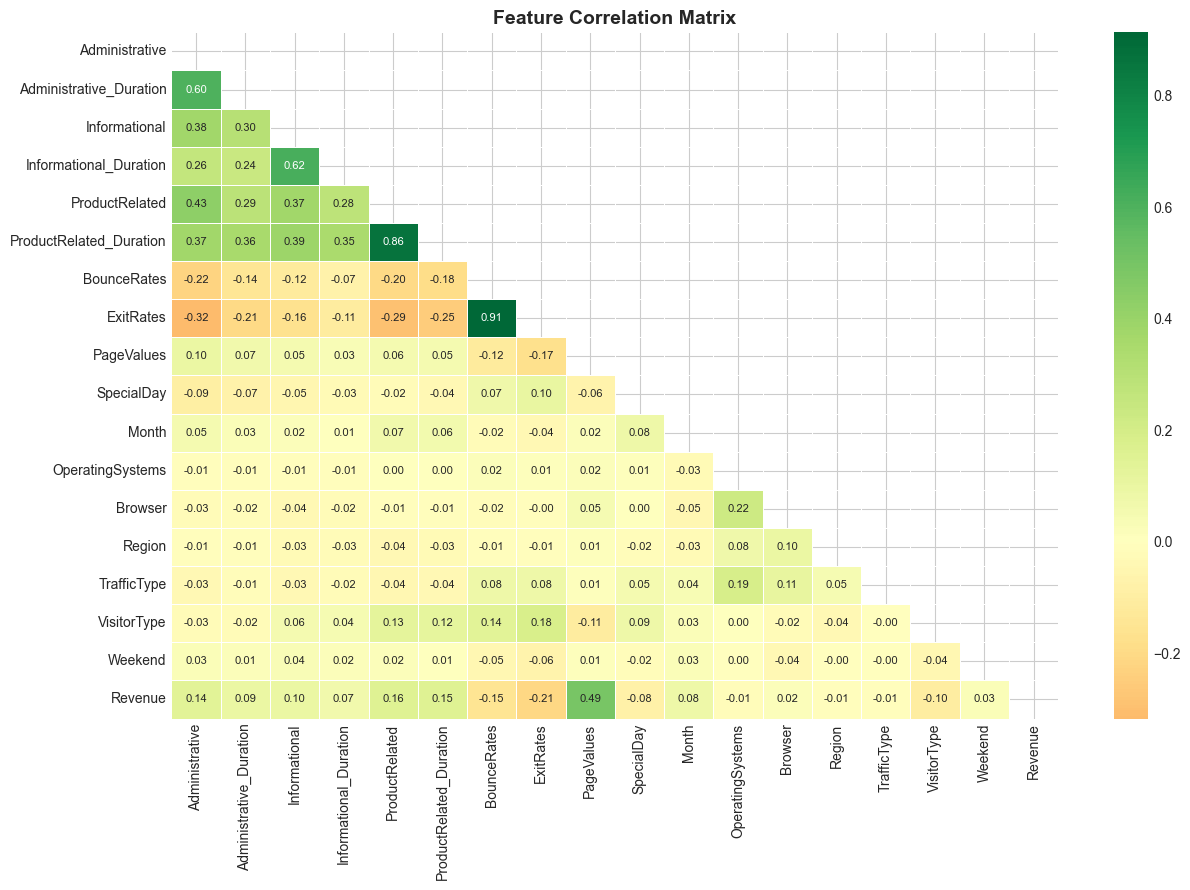

Plot 3 done!


In [16]:
# Correlation Heatmap
plt.figure(figsize=(13, 9))

corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 8})

plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 3 done!")

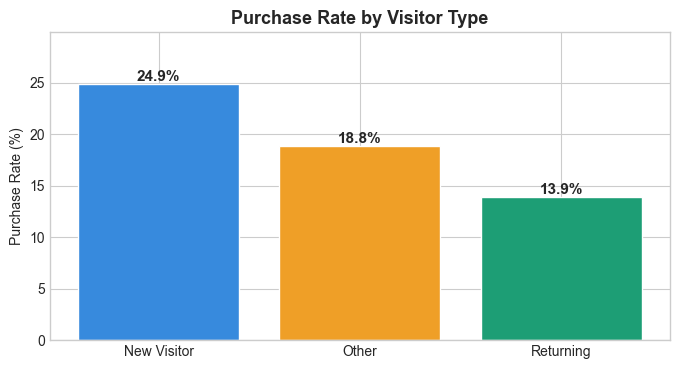

Plot 4 done!


In [17]:
# Visitor Type vs Purchase Rate
plt.figure(figsize=(8, 4))

visitor_names = {0: 'New Visitor', 1: 'Other', 2: 'Returning'}
df['VisitorType_Name'] = df['VisitorType'].map(visitor_names)

visitor_purchase = df.groupby('VisitorType_Name')['Revenue'].mean() * 100
bars = plt.bar(visitor_purchase.index, visitor_purchase.values,
               color=['#378ADD', '#EF9F27', '#1D9E75'], edgecolor='white')

for bar, val in zip(bars, visitor_purchase.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.title('Purchase Rate by Visitor Type', fontsize=13, fontweight='bold')
plt.ylabel('Purchase Rate (%)')
plt.ylim(0, visitor_purchase.max() + 5)
plt.savefig('05_visitor_type.png', dpi=150, bbox_inches='tight')
plt.show()

df.drop('VisitorType_Name', axis=1, inplace=True)
print("Plot 4 done!")

In [18]:
# Top Features correlated with Revenue
print("="*45)
print("TOP FEATURES correlated with Revenue:")
print("="*45)
rev_corr = df.corr(numeric_only=True)['Revenue'].drop('Revenue').abs().sort_values(ascending=False)
for feat, val in rev_corr.items():
    bar = '█' * int(val * 30)
    print(f"{feat:28s} {bar} {val:.3f}")

TOP FEATURES correlated with Revenue:
PageValues                   ██████████████ 0.493
ExitRates                    ██████ 0.207
ProductRelated               ████ 0.159
ProductRelated_Duration      ████ 0.152
BounceRates                  ████ 0.151
Administrative               ████ 0.139
VisitorType                  ███ 0.105
Informational                ██ 0.095
Administrative_Duration      ██ 0.094
SpecialDay                   ██ 0.082
Month                        ██ 0.080
Informational_Duration       ██ 0.070
Weekend                       0.029
Browser                       0.024
OperatingSystems              0.015
Region                        0.012
TrafficType                   0.005


In [ ]:
# FEATURE ENGINEERING

# Naye meaningful features banao
df['total_pages'] = (df['Administrative'] + 
                     df['Informational'] + 
                     df['ProductRelated'])

df['total_duration'] = (df['Administrative_Duration'] + 
                        df['Informational_Duration'] + 
                        df['ProductRelated_Duration'])

df['avg_time_per_page'] = df['total_duration'] / (df['total_pages'] + 1)

# BounceRates and ExitRates almost same (0.91 corr)  make combined metric
df['bounce_exit_avg'] = (df['BounceRates'] + df['ExitRates']) / 2

# High PageValue user flag
df['is_high_value_user'] = (df['PageValues'] > df['PageValues'].median()).astype(int)

# Engagement score
df['engagement_score'] = (
    (1 - df['BounceRates']) * df['PageValues'] * np.log1p(df['total_pages'])
)

print("New features added:")
new_feats = ['total_pages', 'total_duration', 'avg_time_per_page', 
             'bounce_exit_avg', 'is_high_value_user', 'engagement_score']
print(df[new_feats].describe().round(2))

New features added:
       total_pages  total_duration  avg_time_per_page  bounce_exit_avg  \
count     12330.00        12330.00           12330.00         12330.00   
mean         34.55         1310.04              34.79             0.03   
std          46.51         2037.80              33.85             0.05   
min           0.00            0.00               0.00             0.00   
25%           8.00          222.00              16.84             0.01   
50%          20.00          680.00              27.97             0.02   
75%          42.00         1626.91              43.12             0.03   
max         746.00        69921.65             940.67             0.20   

       is_high_value_user  engagement_score  
count            12330.00          12330.00  
mean                 0.22             20.28  
std                  0.42             64.39  
min                  0.00              0.00  
25%                  0.00              0.00  
50%                  0.00            

In [20]:
# Updated X with new features
X = df.drop('Revenue', axis=1)
y = df['Revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler2 = StandardScaler()
X_train_scaled = scaler2.fit_transform(X_train)
X_test_scaled  = scaler2.transform(X_test)

smote2 = SMOTE(random_state=42)
X_train_res, y_train_res = smote2.fit_resample(X_train_scaled, y_train)

print(f"Final training shape: {X_train_res.shape}")
print(f"Features used: {X.shape[1]}")

Final training shape: (16676, 23)
Features used: 23


In [ ]:
# MODEL TRAINING

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
import time

models = {
    'Logistic Regression':   LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':         RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':     GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost':               XGBClassifier(n_estimators=100, random_state=42, 
                                           eval_metric='logloss', verbosity=0)
}

print("="*60)
print(f"{'Model':<25} {'F1 Score':>10} {'Std':>8} {'Time':>8}")
print("="*60)

results = {}
for name, model in models.items():
    start = time.time()
    scores = cross_val_score(model, X_train_res, y_train_res, 
                             cv=5, scoring='f1', n_jobs=-1)
    elapsed = time.time() - start
    results[name] = scores.mean()
    print(f"{name:<25} {scores.mean():>10.4f} {scores.std():>8.4f} {elapsed:>7.1f}s")

print("="*60)
best_name = max(results, key=results.get)
print(f"Best model: {best_name} (F1 = {results[best_name]:.4f})")

Model                       F1 Score      Std     Time
Logistic Regression           0.8455   0.0063    14.2s
Random Forest                 0.9339   0.0213    19.0s
Gradient Boosting             0.9064   0.0681    41.0s
XGBoost                       0.8870   0.1568     3.6s
Best model: Random Forest (F1 = 0.9339)


In [ ]:
# RANDOM FOREST TUNING

from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100, 200, 300],
    'max_depth':    [10, 20, None],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)
grid = GridSearchCV(rf, params, cv=3, scoring='f1', n_jobs=-1, verbose=1)
grid.fit(X_train_res, y_train_res)

print(f"Best parameters: {grid.best_params_}")
print(f"Best F1 score  : {grid.best_score_:.4f}")

best_model = grid.best_estimator_

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}
Best F1 score  : 0.9320


In [ ]:
# MODEL EVALUATION

from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)

# Predictions
y_pred  = best_model.predict(X_test_scaled)
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

# Full classification report
print("="*55)
print("CLASSIFICATION REPORT:")
print("="*55)
print(classification_report(y_test, y_pred, 
      target_names=['No Purchase', 'Purchase']))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

 No Purchase       0.95      0.92      0.93      2084
    Purchase       0.61      0.71      0.66       382

    accuracy                           0.89      2466
   macro avg       0.78      0.81      0.79      2466
weighted avg       0.89      0.89      0.89      2466

ROC-AUC Score: 0.9181



Confusion Matrix breakdown:
True Negative  (sahi 'No Buy' predict): 1912
False Positive (galat 'Buy' predict)  : 172
False Negative (missed buyers)         : 111
True Positive  (sahi 'Buy' predict)   : 271


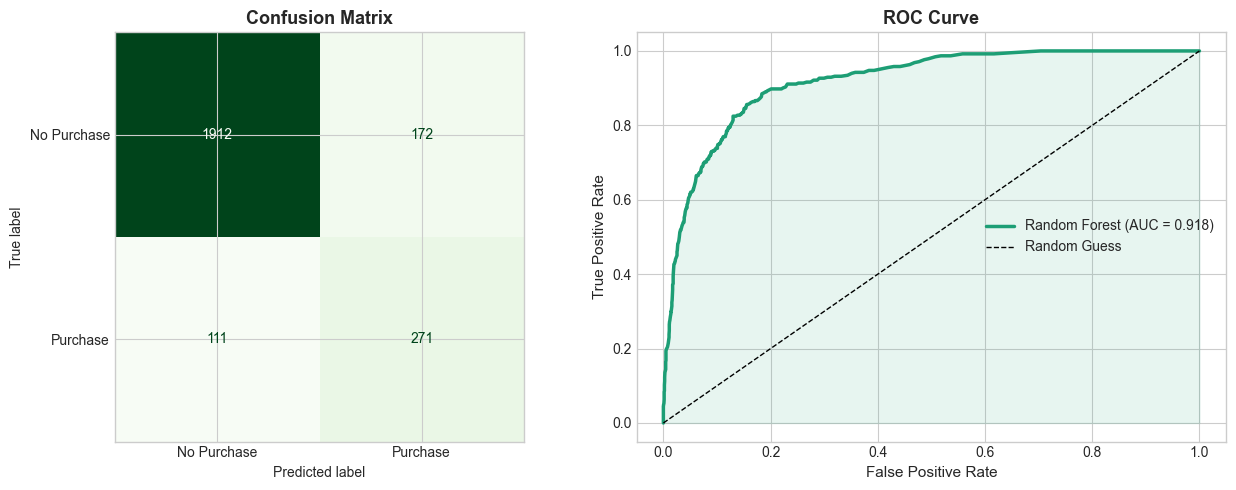

In [ ]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1 — Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Purchase', 'Purchase'])
disp.plot(ax=axes[0], cmap='Greens', colorbar=False)
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')

# Numbers explain
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix breakdown:")
print(f"True Negative  (sahi 'No Buy' predict): {tn}")
print(f"False Positive (galat 'Buy' predict)  : {fp}")
print(f"False Negative (missed buyers)         : {fn}")
print(f"True Positive  (sahi 'Buy' predict)   : {tp}")

# Plot 2 — ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

axes[1].plot(fpr, tpr, color='#1D9E75', linewidth=2.5,
             label=f'Random Forest (AUC = {auc:.3f})')
axes[1].plot([0,1], [0,1], 'k--', linewidth=1, label='Random Guess')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#1D9E75')
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('06_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

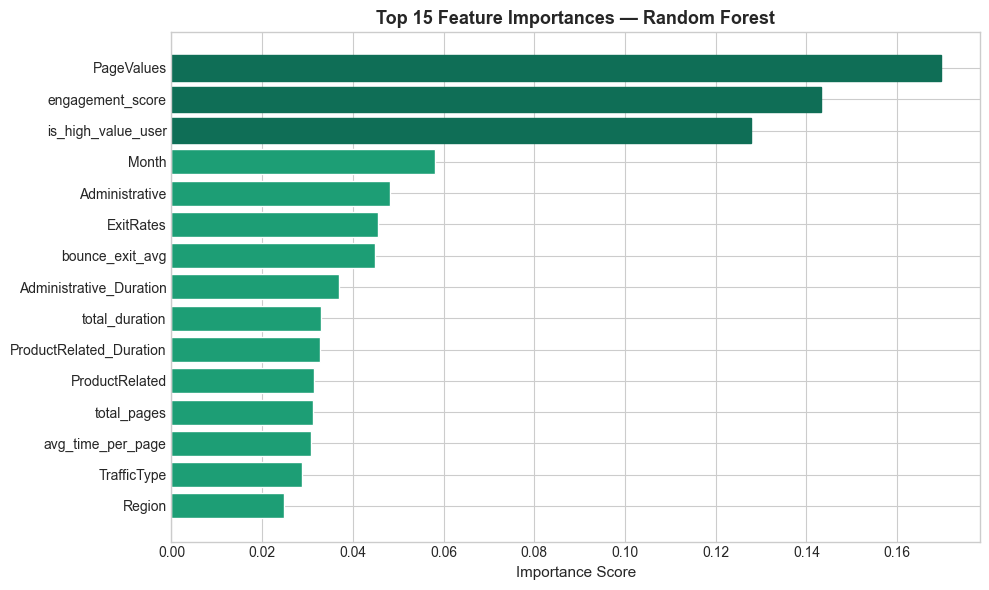


Top 5 most important features:
           Feature  Importance
        PageValues    0.169768
  engagement_score    0.143254
is_high_value_user    0.127673
             Month    0.058126
    Administrative    0.048118


In [ ]:
# Feature Importance - Top 15
importances = best_model.feature_importances_
feat_names  = X.columns
feat_df = (pd.DataFrame({'Feature': feat_names, 'Importance': importances})
             .sort_values('Importance', ascending=True)
             .tail(15))

plt.figure(figsize=(10, 6))
bars = plt.barh(feat_df['Feature'], feat_df['Importance'],
                color='#1D9E75', edgecolor='white')

# Top 3 highlight 
for i, bar in enumerate(bars):
    if i >= 12:  # last 3 = top 3
        bar.set_color('#0F6E56')

plt.xlabel('Importance Score', fontsize=11)
plt.title('Top 15 Feature Importances — Random Forest', 
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('07_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 most important features:")
print(feat_df.tail(5)[['Feature','Importance']]
      .sort_values('Importance', ascending=False)
      .to_string(index=False))

In [ ]:
# MODEL SAVE

import joblib

# Model aur scaler save karo
joblib.dump(best_model, 'purchase_model.pkl')
joblib.dump(scaler2,    'scaler.pkl')

# Feature names bhi save karo
import json
feature_names = list(X.columns)
with open('feature_names.json', 'w') as f:
    json.dump(feature_names, f)

print("Saved files:")
print("  purchase_model.pkl")
print("  scaler.pkl")
print("  feature_names.json")
print(f"\nTotal features: {len(feature_names)}")
print(f"Features: {feature_names}")

Saved files:
  purchase_model.pkl
  scaler.pkl
  feature_names.json

Total features: 23
Features: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'total_pages', 'total_duration', 'avg_time_per_page', 'bounce_exit_avg', 'is_high_value_user', 'engagement_score']
